# E-Commerce Revenue Intelligence — EDA
## Dataset: Brazilian E-Commerce (Olist) — 100K+ real orders

## Objective
Understand the dataset structure and identify key revenue patterns.

## Tables We'll Use
- olist_orders_dataset.csv — order status and timestamps
- olist_order_items_dataset.csv — price and product per order
- olist_order_payments_dataset.csv — payment values
- olist_customers_dataset.csv — customer location

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the key tables
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Customers: (99441, 5)


In [2]:
# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Filter only delivered orders (completed revenue)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print("Total orders:", len(orders))
print("Delivered orders:", len(orders_delivered))
print("Delivery rate:", round(len(orders_delivered)/len(orders)*100, 1), "%")

# Date range of the dataset
print("\nDate range:")
print("From:", orders['order_purchase_timestamp'].min().date())
print("To:", orders['order_purchase_timestamp'].max().date())

Total orders: 99441
Delivered orders: 96478
Delivery rate: 97.0 %

Date range:
From: 2016-09-04
To: 2018-10-17


In [3]:
# Build master revenue table
revenue = items.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),
    product_revenue=('price', 'sum'),
    freight_revenue=('freight_value', 'sum')
).reset_index()

payment_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_totals.columns = ['order_id', 'total_payment']

master = orders_delivered.merge(revenue, on='order_id', how='left')
master = master.merge(payment_totals, on='order_id', how='left')
master = master.merge(customers[['customer_id', 'customer_state']], 
                      on='customer_id', how='left')

master['year'] = master['order_purchase_timestamp'].dt.year
master['month'] = master['order_purchase_timestamp'].dt.month
master['year_month'] = master['order_purchase_timestamp'].dt.to_period('M')

print("Master table:", master.shape)
print("Total revenue: $", round(master['total_payment'].sum(), 2))
print("Avg order value: $", round(master['total_payment'].mean(), 2))
print("Date range:", master['year_month'].min(), "to", master['year_month'].max())

Master table: (96478, 16)
Total revenue: $ 15422461.77
Avg order value: $ 159.86
Date range: 2016-09 to 2018-08


=== Revenue Summary ===
Peak revenue month: 2017-11 — $1,153,528
Total revenue: $15,422,462
Avg monthly revenue: $670,542
Avg order value: $159.86


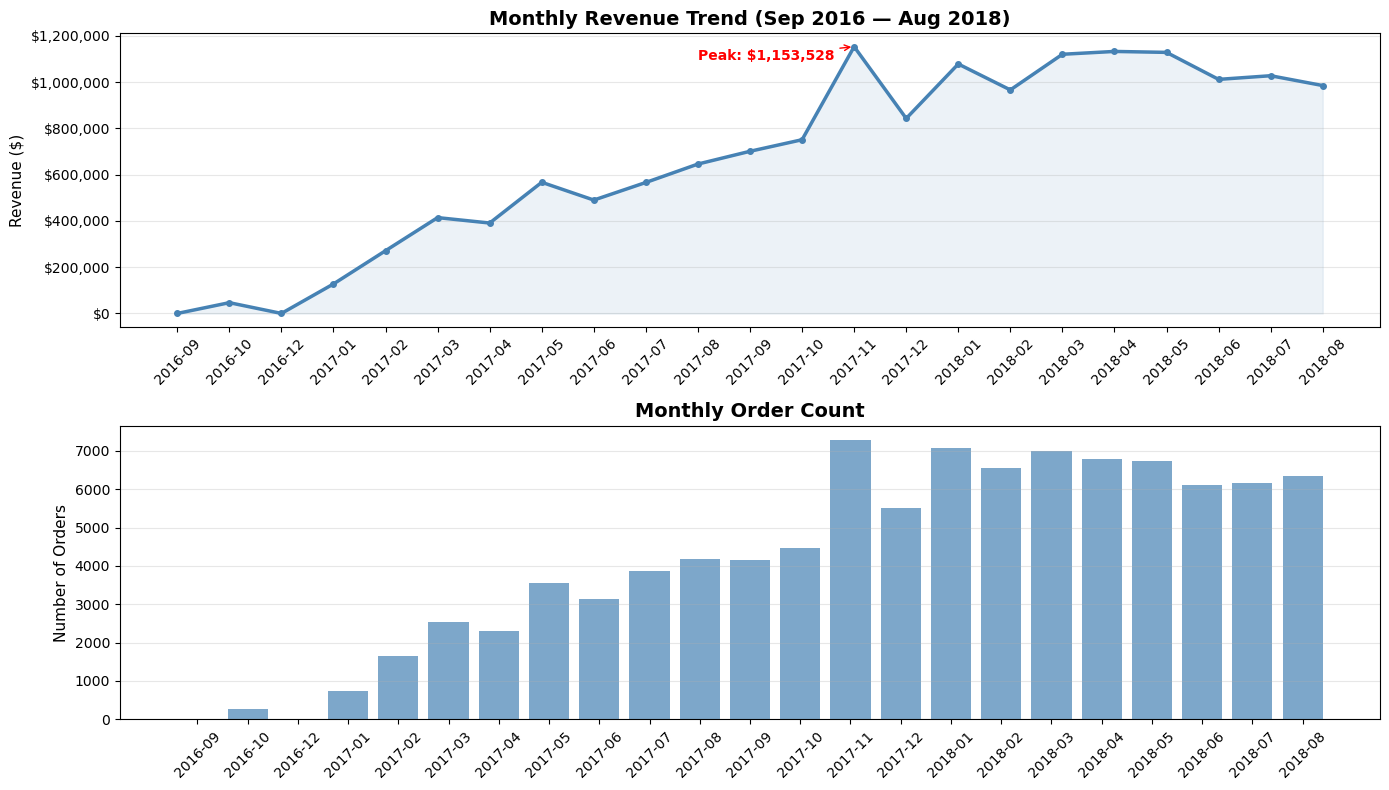


=== Month-over-Month Growth ===
year_month_str  total_revenue  order_count  revenue_growth
       2017-11     1153528.05         7289       53.570258
       2017-12      843199.17         5513      -26.902586
       2018-01     1078606.86         7069       27.918397
       2018-02      966510.88         6555      -10.392663
       2018-03     1120678.00         7003       15.950893
       2018-04     1132933.95         6798        1.093619
       2018-05     1128836.69         6749       -0.361650
       2018-06     1012090.68         6099      -10.342152
       2018-07     1027903.86         6159        1.562427
       2018-08      985414.28         6351       -4.133614


In [4]:
# Monthly revenue trend
monthly_revenue = master.groupby('year_month').agg(
    total_revenue=('total_payment', 'sum'),
    order_count=('order_id', 'count'),
    avg_order_value=('total_payment', 'mean')
).reset_index()

monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)
monthly_revenue['revenue_growth'] = monthly_revenue['total_revenue'].pct_change() * 100

# Find peak month and inflection point
peak_month = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax()]
print("=== Revenue Summary ===")
print(f"Peak revenue month: {peak_month['year_month_str']} — ${peak_month['total_revenue']:,.0f}")
print(f"Total revenue: ${master['total_payment'].sum():,.0f}")
print(f"Avg monthly revenue: ${monthly_revenue['total_revenue'].mean():,.0f}")
print(f"Avg order value: ${master['total_payment'].mean():,.2f}")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1 — Monthly Revenue
axes[0].plot(monthly_revenue['year_month_str'], 
             monthly_revenue['total_revenue'], 
             color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly_revenue)), 
                     monthly_revenue['total_revenue'], 
                     alpha=0.1, color='steelblue')
axes[0].set_title('Monthly Revenue Trend (Sep 2016 — Aug 2018)', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)

# Annotate peak
peak_idx = monthly_revenue['total_revenue'].idxmax()
axes[0].annotate(f"Peak: ${peak_month['total_revenue']:,.0f}",
                xy=(peak_idx, peak_month['total_revenue']),
                xytext=(peak_idx - 3, peak_month['total_revenue'] * 0.95),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10, color='red', fontweight='bold')

# Chart 2 — Order Count
axes[1].bar(monthly_revenue['year_month_str'], 
            monthly_revenue['order_count'],
            color='steelblue', alpha=0.7)
axes[1].set_title('Monthly Order Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Month-over-Month Growth ===")
print(monthly_revenue[['year_month_str', 'total_revenue', 'order_count', 
                        'revenue_growth']].tail(10).to_string(index=False))

## Key Finding #1 — Revenue Growth Plateau

- Peak month: November 2017 — $1,153,528
- Post-peak: Revenue oscillates between $843K–$1.13M with no clear upward trend
- Order count stabilized at ~6,500–7,000/month from Jan 2018 onward
- Growth rate dropped from 53% MoM (Nov 2017) to flat/negative in 2018

**Business Question this raises:**
Is the plateau driven by:
- Fewer new customers? (acquisition problem)
- Lower repeat purchases? (retention problem)
- Lower order values? (pricing/product problem)

→ RFM segmentation will answer this next.

In [5]:
# RFM Analysis — Who are our best customers?
from datetime import datetime

# Reference date = day after last order
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics per customer
rfm = master.groupby('customer_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('total_payment', 'sum')
).reset_index()

# Score each metric 1-4 (4 = best)
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, 
                          labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment customers
def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

# Summary
segment_summary = rfm.groupby('Segment').agg(
    customer_count=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
).round(1)

segment_summary['customer_pct'] = (
    segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100
).round(1)

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("=== RFM Customer Segmentation ===")
print(segment_summary.to_string())

=== RFM Customer Segmentation ===
           customer_count  avg_monetary  total_revenue  revenue_pct  customer_pct
Segment                                                                          
Loyal               32942        188.79     6219175.14         40.3          34.1
Champions           15301        275.64     4217573.06         27.3          15.9
Potential           33024        121.82     4023104.88         26.1          34.2
At Risk             13660         65.61      896197.92          5.8          14.2
Lost                 1551         42.82       66410.77          0.4           1.6


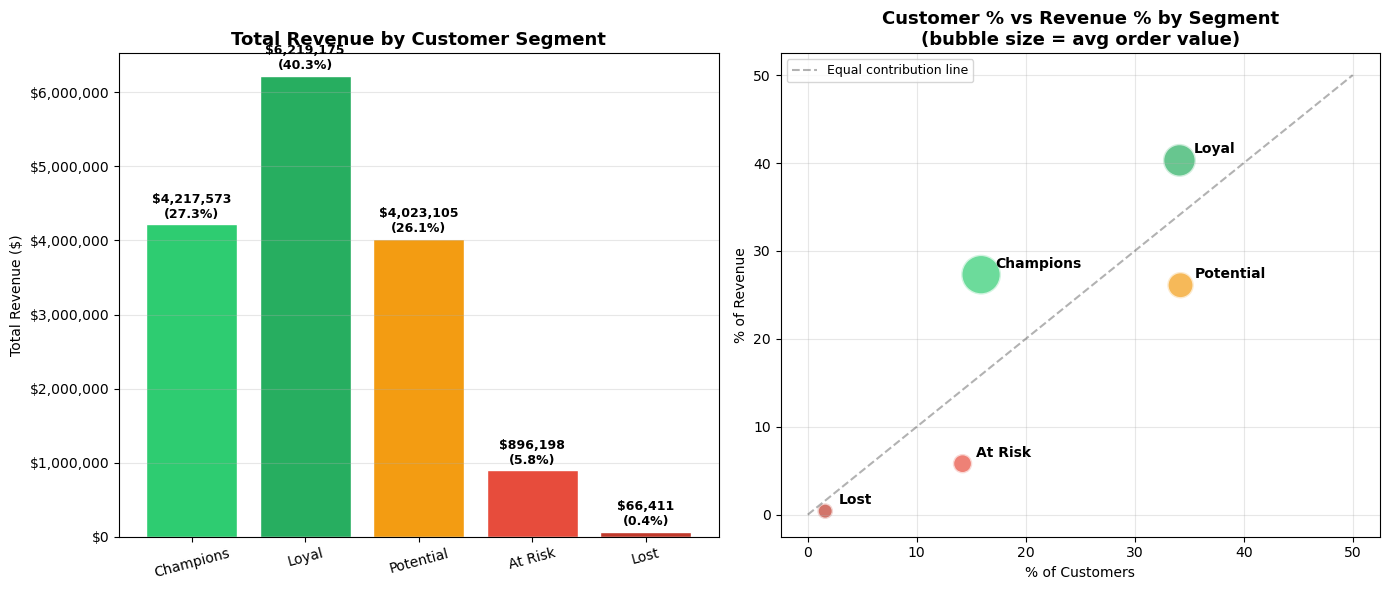

In [6]:
# Visualize RFM Segments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_order = ['Champions', 'Loyal', 'Potential', 'At Risk', 'Lost']
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']

# Chart 1 — Revenue by Segment
seg_plot = segment_summary.reindex(segment_order)
bars = axes[0].bar(seg_plot.index, seg_plot['total_revenue'],
                   color=colors, edgecolor='white')
for bar, val, pct in zip(bars, seg_plot['total_revenue'], seg_plot['revenue_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                f'${val:,.0f}\n({pct}%)', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
axes[0].set_title('Total Revenue by Customer Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 — Customer Count vs Revenue % (bubble insight)
x = seg_plot['customer_pct']
y = seg_plot['revenue_pct']
sizes = seg_plot['avg_monetary'] * 3

axes[1].scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidth=2)
for i, seg in enumerate(segment_order):
    axes[1].annotate(seg,
                    (x[seg], y[seg]),
                    textcoords='offset points',
                    xytext=(10, 5),
                    fontsize=10, fontweight='bold')

axes[1].set_title('Customer % vs Revenue % by Segment\n(bubble size = avg order value)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('% of Customers')
axes[1].set_ylabel('% of Revenue')
axes[1].plot([0, 50], [0, 50], 'k--', alpha=0.3, label='Equal contribution line')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Key Finding #2 — RFM Customer Segmentation

| Segment | Customers | Revenue | Avg Order Value |
|---|---|---|---|
| Champions | 15,301 (15.9%) | $4.2M (27.3%) | $275 |
| Loyal | 32,942 (34.1%) | $6.2M (40.3%) | $188 |
| Potential | 33,024 (34.2%) | $4.0M (26.1%) | $121 |
| At Risk | 13,660 (14.2%) | $896K (5.8%) | $65 |
| Lost | 1,551 (1.6%) | $66K (0.4%) | $42 |

**Critical Insight:**
- Champions + Loyal = 50% of customers but generate 67.6% of revenue
- Champions spend 6.4x more per order than At Risk customers ($275 vs $43)
- 13,660 At Risk customers represent $896K at risk of being lost permanently

**Business Recommendation:**
- Protect Champions with VIP loyalty program — losing them costs $275/order
- Re-engage 13,660 At Risk customers with targeted win-back campaign
- Convert Potential to Loyal with personalized recommendations

=== Delivery Performance Analysis ===
                         order_count  avg_order_value  total_revenue  order_pct
delivery_speed                                                                 
1. Fast (≤7 days)              33683           140.49     4732274.93       34.9
2. Normal (8-14 days)          36397           163.14     5937905.67       37.8
3. Slow (15-21 days)           15369           174.86     2687400.18       15.9
4. Very Slow (21+ days)        10944           186.86     2044845.54       11.4


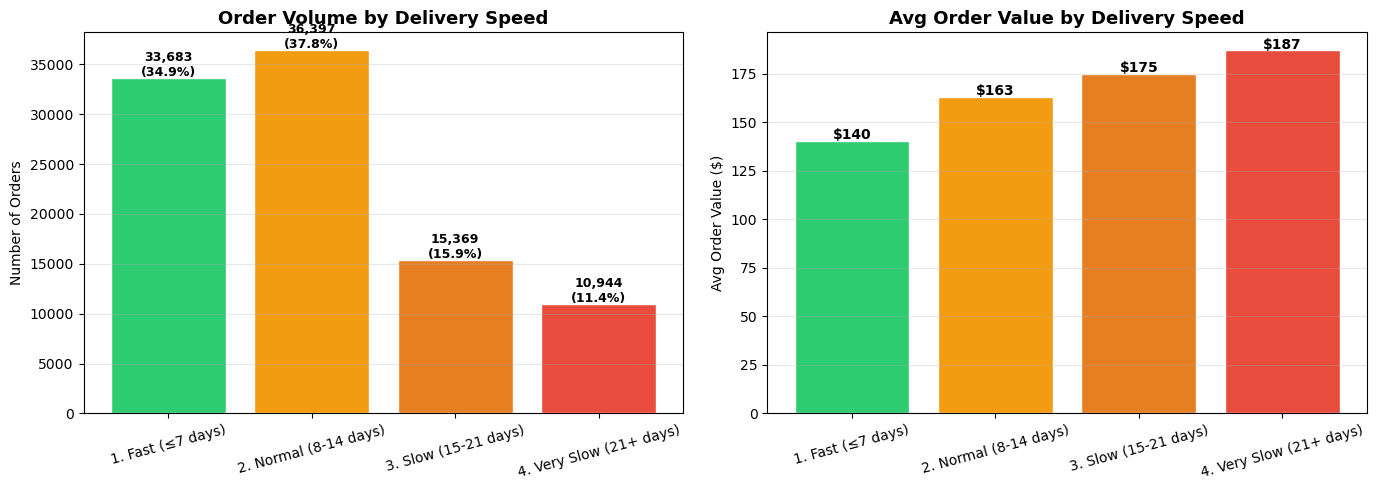

In [7]:
# Delivery Performance vs Revenue Analysis
# Calculate delivery delay
master['delivery_delay_days'] = (
    master['order_delivered_customer_date'] - 
    master['order_purchase_timestamp']
).dt.days

# Remove nulls and outliers
delivery = master.dropna(subset=['delivery_delay_days'])
delivery = delivery[delivery['delivery_delay_days'] > 0]
delivery = delivery[delivery['delivery_delay_days'] < 100]

# Bucket delivery speed
def delivery_bucket(days):
    if days <= 7:
        return '1. Fast (≤7 days)'
    elif days <= 14:
        return '2. Normal (8-14 days)'
    elif days <= 21:
        return '3. Slow (15-21 days)'
    else:
        return '4. Very Slow (21+ days)'

delivery['delivery_speed'] = delivery['delivery_delay_days'].apply(delivery_bucket)

# Revenue and order value by delivery speed
delivery_analysis = delivery.groupby('delivery_speed').agg(
    order_count=('order_id', 'count'),
    avg_order_value=('total_payment', 'mean'),
    total_revenue=('total_payment', 'sum')
).round(2)

delivery_analysis['order_pct'] = (
    delivery_analysis['order_count'] / delivery_analysis['order_count'].sum() * 100
).round(1)

print("=== Delivery Performance Analysis ===")
print(delivery_analysis.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Chart 1 — Order count by delivery speed
bars = axes[0].bar(delivery_analysis.index,
                   delivery_analysis['order_count'],
                   color=colors, edgecolor='white')
for bar, val, pct in zip(bars, delivery_analysis['order_count'],
                          delivery_analysis['order_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}\n({pct}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Order Volume by Delivery Speed', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Chart 2 — Avg order value by delivery speed
bars2 = axes[1].bar(delivery_analysis.index,
                    delivery_analysis['avg_order_value'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars2, delivery_analysis['avg_order_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Avg Order Value by Delivery Speed', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Key Finding #3 — Delivery Performance

| Delivery Speed | Orders | % of Total | Avg Order Value |
|---|---|---|---|
| Fast (≤7 days) | 33,683 | 34.9% | $140 |
| Normal (8-14 days) | 36,397 | 37.8% | $163 |
| Slow (15-21 days) | 15,369 | 15.9% | $175 |
| Very Slow (21+ days) | 10,944 | 11.4% | $187 |

**Insight:** Higher value orders take longer to deliver — likely due to
heavier/bulkier products requiring more complex logistics.

**Business Implication:**
- 27.3% of orders (26,313) take 15+ days — prime candidates for
  proactive delivery communication to reduce negative reviews
- Fast delivery customers spend less — opportunity to upsell
  premium shipping for high-value orders

=== Top 10 States by Revenue ===
                total_revenue  order_count  avg_order_value  unique_customers  revenue_pct
customer_state                                                                            
SP                 5770266.19        40501           142.48             40501         37.4
RJ                 2055690.45        12350           166.45             12350         13.3
MG                 1819277.61        11354           160.23             11354         11.8
RS                  861802.40         5345           161.24              5345          5.6
PR                  781919.55         4923           158.83              4923          5.1
SC                  595208.40         3546           167.85              3546          3.9
BA                  591270.60         3256           181.59              3256          3.8
DF                  346146.17         2080           166.42              2080          2.2
GO                  334294.22         1957           170.

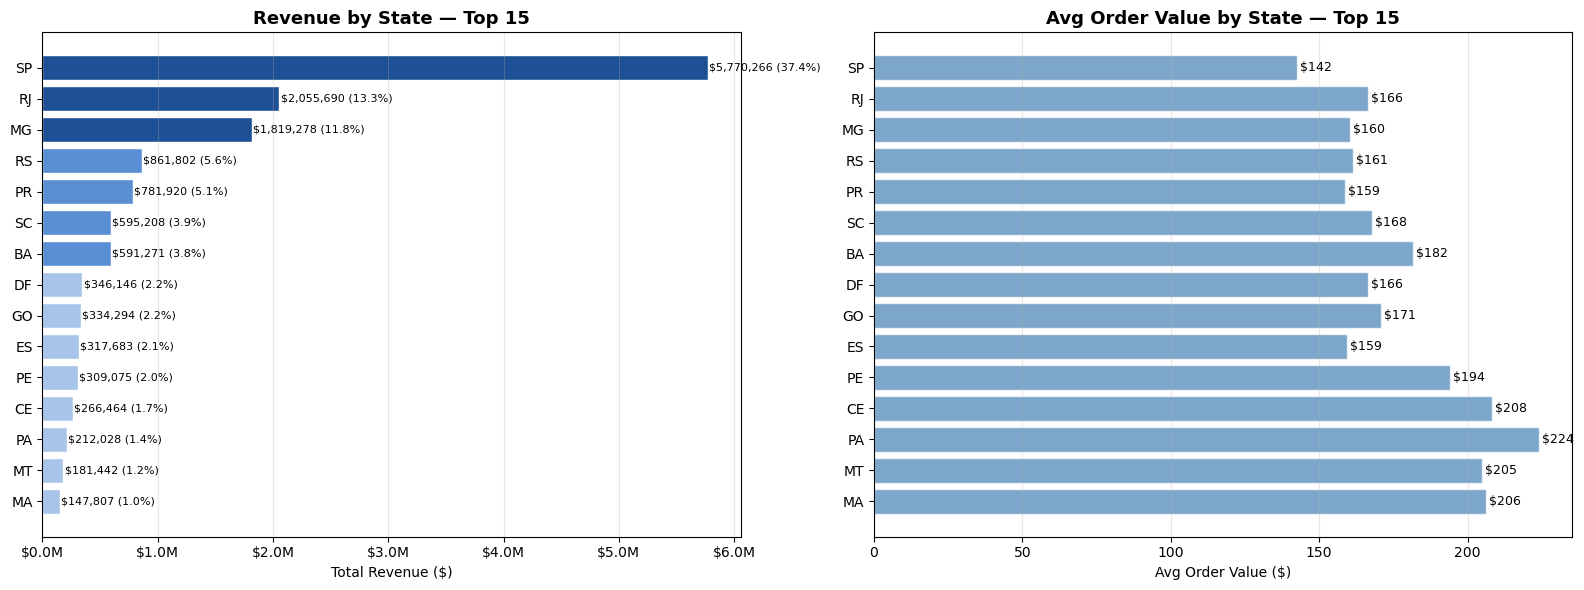

In [8]:
# State-Level Revenue Analysis
state_revenue = master.groupby('customer_state').agg(
    total_revenue=('total_payment', 'sum'),
    order_count=('order_id', 'count'),
    avg_order_value=('total_payment', 'mean'),
    unique_customers=('customer_id', 'nunique')
).round(2)

state_revenue['revenue_pct'] = (
    state_revenue['total_revenue'] / state_revenue['total_revenue'].sum() * 100
).round(1)

state_revenue = state_revenue.sort_values('total_revenue', ascending=False)

print("=== Top 10 States by Revenue ===")
print(state_revenue.head(10).to_string())

print(f"\nTop 5 states generate: {state_revenue.head(5)['revenue_pct'].sum():.1f}% of total revenue")

# Visualize top 15 states
top_states = state_revenue.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Revenue by state
colors_bar = ['#1e5096' if i < 3 else '#5b8fd4' if i < 7 else '#a8c4e8' 
               for i in range(len(top_states))]
bars = axes[0].barh(top_states.index[::-1], 
                    top_states['total_revenue'][::-1],
                    color=colors_bar[::-1], edgecolor='white')
for bar, val, pct in zip(bars, 
                          top_states['total_revenue'][::-1],
                          top_states['revenue_pct'][::-1]):
    axes[0].text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f} ({pct}%)', va='center', fontsize=8)
axes[0].set_title('Revenue by State — Top 15', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].grid(axis='x', alpha=0.3)

# Chart 2 — Avg order value by state (top 15)
axes[1].barh(top_states.index[::-1],
             top_states['avg_order_value'][::-1],
             color='steelblue', alpha=0.7, edgecolor='white')
for i, (idx, row) in enumerate(top_states[::-1].iterrows()):
    axes[1].text(row['avg_order_value'] + 1, i,
                f'${row["avg_order_value"]:.0f}', va='center', fontsize=9)
axes[1].set_title('Avg Order Value by State — Top 15', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Order Value ($)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Key Finding #4 — Geographic Revenue Intelligence

**Top 5 States = 73.2% of Revenue:**
- SP (São Paulo): $5.77M — 37.4% of total
- RJ (Rio de Janeiro): $2.06M — 13.3%
- MG (Minas Gerais): $1.82M — 11.8%
- RS (Rio Grande do Sul): $862K — 5.6%
- PR (Paraná): $782K — 5.1%

**Hidden Insight — High AOV States:**
- PA: $224 avg order value but only 1.4% of revenue
- CE: $208 avg order value but only 1.7% of revenue
- These states have high-value customers but low penetration

**Business Recommendation:**
- Protect SP dominance — any churn here is catastrophic
- Growth opportunity: PA and CE have high-value buyers but low volume
  — targeted marketing could unlock significant revenue